In [2]:
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt


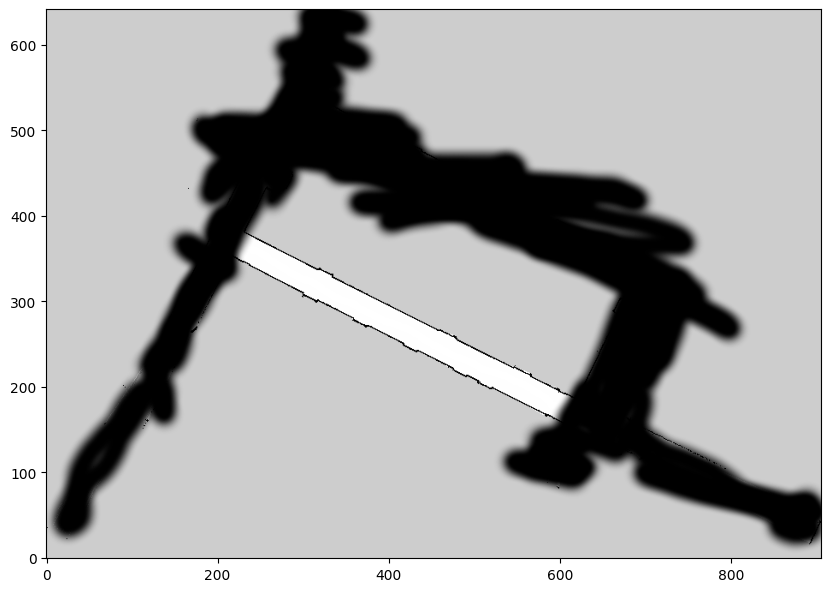

In [5]:
map_img='/Users/bryanalfaro/Documents/Problem_Sets/ese6500_final/f1tenth_gym/maps/levine_hall1/levine_hall1_map.png'
map_img = np.array(Image.open(map_img).transpose(Image.FLIP_TOP_BOTTOM))
plt.figure(figsize=(10, 10))
plt.imshow(map_img, cmap='gray', origin='lower')

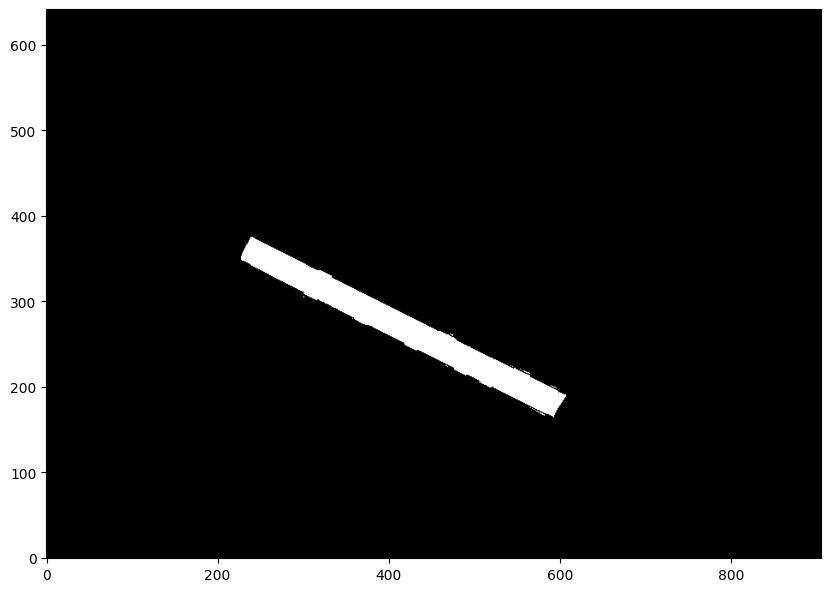

In [6]:
map_img = map_img > 210
plt.figure(figsize=(10, 10))
plt.imshow(map_img, cmap='gray', origin='lower')

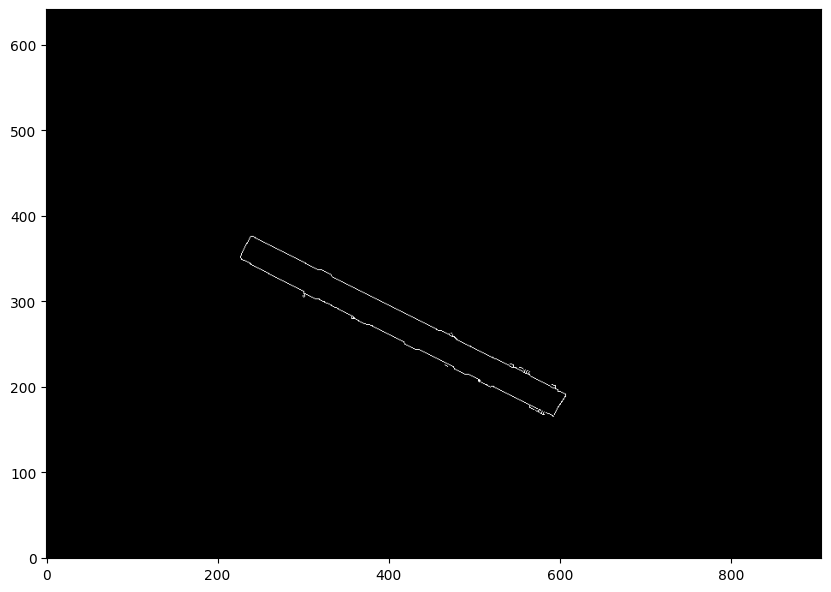

In [22]:
edges = cv2.Canny(255 * map_img.astype(np.uint8), 10, 300, 3)
edges= cv2.morphologyEx(edges, cv2.MORPH_CLOSE, (7,7))
plt.figure(figsize=(10, 10))
plt.imshow(edges, cmap='gray', origin='lower')

(61, 4)


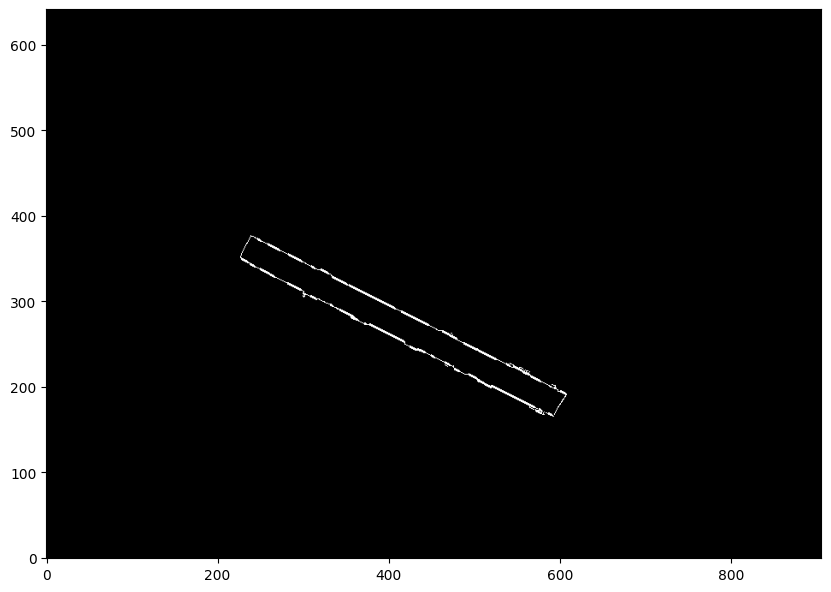

In [59]:
lines = cv2.HoughLines(edges, 3, np.deg2rad(1), 100)
line_ends = cv2.HoughLinesP(edges, 3, np.deg2rad(1), 35).squeeze()
# print(lines)
print(line_ends.shape)
disp_lines = np.zeros_like(edges)
# if lines is not None:
#     for i in range(len(lines)):
#         rho = lines[i][0][0] + 10
#         theta = lines[i][0][1]
#         a = np.cos(theta)
#         b = np.sin(theta)
#         x0 = a * rho
#         y0 = b * rho
#         pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
#         pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
#         cv2.line(disp_lines, pt1, pt2, (255,255,255), 1, cv2.LINE_AA)
for r in line_ends:
    cv2.line(disp_lines, (r[0], r[1]), (r[2], r[3]), (255,255,255), 1, cv2.LINE_AA)
plt.figure(figsize=(10, 10))
# plt.imshow(disp_lines, cmap='gray', origin='lower')
plt.imshow(np.logical_or(disp_lines, edges), cmap='gray', origin='lower')